In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, silhouette_score
)


## 1. Load and Clean Data

In [3]:
# --- First Stape load an Clean data ---

#path = '/kaggle/input/datasets/mamadoulaminefallai/hakathon-week6/train.csv' # Kaggle path
path = r"C:\Users\bmd tech\Desktop\Spark Academy\Week6\SPARK-TEAM-2-SENEGAL\Hackaton week 6\data\train.csv"
train_df = pd.read_csv(f"{path}")      # chage path if run localy

train_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,1


In [4]:
train_df.iloc[50:56]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
50,340,39,Male,Hungary,non-anginal,120.0,339.0,False,normal,170.0,False,0.0,NaN,NaN,NaN,0
51,111,61,Female,Cleveland,asymptomatic,145.0,307.0,False,lv hypertrophy,146.0,True,1.0,flat,0.0,reversable defect,1
52,120,65,Male,Cleveland,asymptomatic,135.0,254.0,False,lv hypertrophy,127.0,False,2.8,flat,1.0,reversable defect,1
53,157,51,Male,Cleveland,asymptomatic,140.0,299.0,False,normal,173.0,True,1.6,upsloping,0.0,reversable defect,1
54,388,46,Male,Hungary,asymptomatic,180.0,280.0,False,st-t abnormality,120.0,False,0.0,NaN,NaN,NaN,0
55,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1


In [5]:
train_df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
731,834,72,Male,VA Long Beach,asymptomatic,NaN,211.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,1
732,243,49,Female,Cleveland,asymptomatic,130.0,269.0,False,normal,163.0,False,0.0,upsloping,0.0,normal,0
733,710,66,Male,Switzerland,asymptomatic,150.0,0.0,False,normal,108.0,True,2.0,flat,NaN,reversable defect,1
734,22,58,Female,Cleveland,typical angina,150.0,283.0,True,lv hypertrophy,162.0,False,1.0,upsloping,0.0,normal,0
735,318,35,Male,Hungary,atypical angina,120.0,308.0,False,lv hypertrophy,180.0,False,0.0,NaN,NaN,NaN,0


In [6]:
print(f"---- DataFrame Shape: {train_df.shape} ----\n")
print("="*60,f"Columns Name : {"="*60} \n {list(train_df.columns)}\n", "="*135)

---- DataFrame Shape: (736, 16) ----

============================================================ Columns Name : ============================================================ 
 ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


# 1.1 Let's take some statistique to nown the dataset

In [7]:
# ── Basic data inspection ──
print("--- Data Types ---")
print(train_df.dtypes)

--- Data Types ---
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object


In [8]:
print(f"\n--- Missing Values ---")
print(train_df.isnull().sum())

train_df.columns.tolist()


--- Missing Values ---
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     50
chol         27
fbs          68
restecg       0
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
target        0
dtype: int64


['id',
 'age',
 'sex',
 'dataset',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

# 1.2 Repartition of Heart Disease

In [9]:
print(f"\n--- target Distribution ---")
print(train_df['target'].value_counts())
print(f"\nHeart disease prevalence: {train_df['target'].mean():.1%}")


--- target Distribution ---
target
1    407
0    329
Name: count, dtype: int64

Heart disease prevalence: 55.3%


---
# 1.3 🧾 Features Description
---


| Column     | Description |
|-----------|------------|
| id        | Unique identifier for each patient |
| age       | Age of the patient (years) |
| sex       | Biological sex (Male, Female) |
| cp        | Chest pain type (typical angina, atypical angina, non-anginal, asymptomatic) |
| trestbps  | Resting blood pressure (mmHg) |
| chol      | Serum cholesterol (mg/dl) |
| fbs       | Fasting blood sugar > 120 mg/dl (True/False) |
| restecg   | Resting ECG results |
| thalach   | Maximum heart rate achieved |
| exang     | Exercise-induced angina (True/False) |
| oldpeak   | ST depression induced by exercise |
| slope     | Slope of peak exercise ST segment |
| ca        | Number of major vessels (0–3) *(may contain missing values)* |
| thal      | Thalassemia type *(may contain missing values)* |
| origin    | Data collection site |
| target    | Target variable (0 = no disease, 1 = disease) *(train only)* |



---
# 1.4 Data Cleaning
---
✅ Explication

trestbps : tension artérielle au repos → jamais 0.

chol : cholestérol sanguin → jamais 0.

thalach : fréquence cardiaque max → jamais 0.

oldpeak : dépression ST → 0 peut exister, mais souvent utilisé comme valeur manquante.

slope : pente du segment ST → codée en catégories, donc 0 = manquant.

ca : nombre de vaisseaux colorés → 0 peut être valide, mais souvent utilisé comme manquant.

thal : thalassémie → 0 = manquant.


In [10]:
# --- Check for impossible zero values (missing data coded as 0) ---
zero_cols = ['trestbps','chol','fbs','thalch','exang','oldpeak','slope','ca','thal'] 
print("--- Count of zero values ( missing data) ---")

for col in zero_cols:
    nbr_zeros = (train_df[col] == 0).sum()
    pct = nbr_zeros / len(train_df) * 100
    print(f"  {col:15s}: {nbr_zeros:8d} zeros ({pct:.1f}%)")


print(f"\n--- Total complete cases --- : {train_df.dropna().shape[0]} / {len(train_df)}")  # case complette sans zeros

--- Count of zero values ( missing data) ---
  trestbps       :        0 zeros (0.0%)
  chol           :      132 zeros (17.9%)
  fbs            :      560 zeros (76.1%)
  thalch         :        0 zeros (0.0%)
  exang          :      416 zeros (56.5%)
  oldpeak        :      288 zeros (39.1%)
  slope          :        0 zeros (0.0%)
  ca             :      151 zeros (20.5%)
  thal           :        0 zeros (0.0%)

--- Total complete cases --- : 246 / 736


# Ce qu’il faut garder en tête
* Taux de valeurs manquantes : 
par exemple fbs a 76 % de valeurs manquantes. Ici, l’imputation risque d’être peu fiable, et il peut être préférable de supprimer la variable si elle n’est pas cruciale.

* Impact sur le modèle : 
certaines variables comme (chol) ou (ca) sont probablement importantes pour la prédiction, donc mieux vaut les conserver avec une imputation adaptée.


# ⚠️ Attention aux proportions
* fbs a 76% de valeurs manquantes → imputer par la moyenne ou le mode risque de créer un biais énorme. Dans ce cas, soit on considères que la variable n’apporte pas assez d’information et on l’exclus, soit on utilises une méthode avancée.

* exang (angine induite par l’effort) a 56% manquants → même problème, il faut réfléchir si la variable est exploitable.

* Les autres variables avec 20–40% de manquants (chol, oldpeak, ca) peuvent être imputées sans trop de perte si on choisis bien la méthode.

In [11]:
# ── Replace impossible zeros with NaN for cleaner analysis ──
# Colonnes où les zéros sont impossibles
zero_imp = ['trestbps','chol','thalch','oldpeak','slope','ca','thal']

train_df = train_df.copy()

for col in zero_imp :
   train_df[col] = train_df[col].replace(0, np.nan)

# Suppression des valeur null
#train_df.dropna(axis=0 ,inplace=True)

# Vérification
print(train_df[zero_imp].isnull().sum(),"\n")
train_df.head()


trestbps     50
chol        159
thalch       47
oldpeak     340
slope       241
ca          636
thal        381
dtype: int64 



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,NaN,NaN,lv hypertrophy,122.0,True,NaN,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,NaN,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,655,56,Male,Switzerland,non-anginal,155.0,NaN,False,st-t abnormality,99.0,False,NaN,flat,NaN,normal,1


# Une approche pragmatique serait :

* Supprimer les variables avec trop de valeurs manquantes (fbs par exemple).
* Imputer les variables numériques avec la médiane.
* Imputer les variables catégorielles avec le mode

In [12]:
# Séparer numériques et catégorielles
num_cols = train_df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
print(cat_cols)
print(num_cols)

# Imputation
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

train_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])

# Supprimer colonnes inutiles
train_df = train_df.drop(columns=["id", "dataset","fbs","exang"])
train_df.head()

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target']


,age,sex,cp,trestbps,chol,restecg,thalch,oldpeak,slope,ca,thal,target
0,53.0,Male,non-anginal,160.0,239.0,lv hypertrophy,122.0,1.5,flat,1.0,reversable defect,1.0
1,74.0,Male,non-anginal,130.0,239.0,normal,140.0,1.5,flat,1.0,normal,0.0
2,53.0,Male,asymptomatic,124.0,243.0,normal,122.0,2.0,flat,1.0,reversable defect,1.0
3,61.0,Male,asymptomatic,140.0,207.0,lv hypertrophy,138.0,1.9,upsloping,1.0,reversable defect,1.0
4,56.0,Male,non-anginal,155.0,239.0,st-t abnormality,99.0,1.5,flat,1.0,normal,1.0


---

## 2. Preparing Numerical Data 
---
Before feeding data into any ML algorithm, we need to prepare it properly. 

**data splitting, normalisation, and feature selection**.

---

In [13]:
# Encodage
features = pd.get_dummies(train_df.drop(columns=["target"]), drop_first=True)
target = train_df["target"]
features = features.astype(int)
# --- Separate features and target ---
# --- Split the dataset (80% train, 20% test, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target)

print(f"--Training set-- {X_train.shape[0]} patients --({y_train.mean():.1%} Heart Disease)")
print(f"--Testing set--  {X_test.shape[0]} patients --({y_test.mean():.1%} Heart Disease)")
print("✅ Class proportions preserved in both sets (stratified split)")


--Training set-- 588 patients --(55.3% Heart Disease)
--Testing set--  148 patients --(55.4% Heart Disease)
✅ Class proportions preserved in both sets (stratified split)


In [14]:
features.head(10)

,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,53,160,239,122,1,1,1,0,1,0,0,0,1,0,0,1
1,74,130,239,140,1,1,1,0,1,0,1,0,1,0,1,0
2,53,124,243,122,2,1,1,0,0,0,1,0,1,0,0,1
3,61,140,207,138,1,1,1,0,0,0,0,0,0,1,0,1
4,56,155,239,99,1,1,1,0,1,0,0,1,1,0,1,0
5,40,140,239,188,1,1,1,0,1,0,1,0,1,0,1,0
6,51,130,227,140,1,1,1,0,0,0,0,1,1,0,1,0
7,54,130,239,140,1,1,1,0,0,0,0,1,1,0,1,0
8,52,160,246,82,4,1,1,0,0,0,0,1,1,0,1,0
9,67,120,229,129,2,2,1,0,0,0,0,0,1,0,0,1


## 3. Normalisation :

In [15]:

# ── Standardise the features ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on training data ONLY
X_test_scaled = scaler.transform(X_test)          # Apply same transformation to test

print("Before scaling (first patient in training set):")
print(dict(zip(features.columns, X_train.iloc[0].values)))
print("\nAfter scaling (same patient):")
print(dict(zip(features.columns, X_train_scaled[0].round(2))))
print("\n💡 Notice: all values are now centred around 0 with similar scale")


Before scaling (first patient in training set):
{'age': 69, 'trestbps': 130, 'chol': 210, 'thalch': 140, 'oldpeak': 1, 'ca': 1, 'sex_Male': 1, 'cp_atypical angina': 0, 'cp_non-anginal': 0, 'cp_typical angina': 0, 'restecg_normal': 0, 'restecg_st-t abnormality': 1, 'slope_flat': 1, 'slope_upsloping': 0, 'thal_normal': 1, 'thal_reversable defect': 0}

After scaling (same patient):
{'age': 1.65, 'trestbps': -0.1, 'chol': -0.65, 'thalch': 0.07, 'oldpeak': -0.16, 'ca': -0.25, 'sex_Male': 0.54, 'cp_atypical angina': -0.48, 'cp_non-anginal': -0.55, 'cp_typical angina': -0.22, 'restecg_normal': -1.2, 'restecg_st-t abnormality': 1.99, 'slope_flat': 0.65, 'slope_upsloping': -0.55, 'thal_normal': 0.59, 'thal_reversable defect': -0.52}

💡 Notice: all values are now centred around 0 with similar scale


## 3. Features Selection :

In [29]:
# ── ANOVA F-Score Feature Selection ──
k = 10  # Select top 10 features
anova_selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = anova_selector.fit_transform(X_train_scaled, y_train)
X_test_selected = anova_selector.transform(X_test_scaled)

# ── Display F-scores for all features ──
anova_scores = anova_selector.scores_
anova_results = pd.DataFrame({
    'Feature': features.columns,
    'F-Score': anova_scores
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print("── ANOVA F-Scores (higher = more discriminative) ──\n")
print(anova_results.to_string(index=False))

# ── Identify selected features ──
selected_mask = anova_selector.get_support()
selected_features = features.columns[selected_mask]
print(f"\n✅ Top {k} features selected: {list(selected_features)}")

── ANOVA F-Scores (higher = more discriminative) ──

                 Feature    F-Score
                  thalch 110.202518
      cp_atypical angina  98.243535
                     age  69.105895
                sex_Male  68.276238
             thal_normal  51.424429
  thal_reversable defect  42.974309
                 oldpeak  35.317320
          cp_non-anginal  25.491623
         slope_upsloping  23.426942
                      ca  14.635927
              slope_flat  11.073098
                trestbps  10.326173
          restecg_normal   9.114383
restecg_st-t abnormality   6.418098
                    chol   5.933939
       cp_typical angina   1.832442

✅ Top 10 features selected: ['age', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


In [30]:
selected_features

Index(['age', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina',
       'cp_non-anginal', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

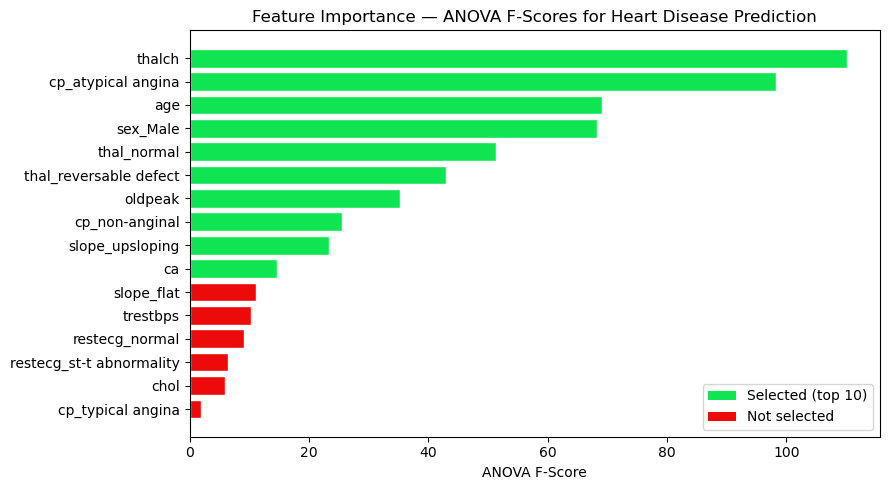

In [31]:
# ── Visualise ANOVA F-Scores ──
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#0fe553' if s else "#ec0a0a" for s in selected_mask[anova_results.index]]
bars = ax.barh(anova_results['Feature'], anova_results['F-Score'],
               color=["#0fe553" if f in selected_features else '#ec0a0a'
                      for f in anova_results['Feature']],
               edgecolor='white')
ax.set_xlabel('ANOVA F-Score')
ax.set_title('Feature Importance — ANOVA F-Scores for Heart Disease Prediction')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#0fe553", label='Selected (top 10)'),
                   Patch(facecolor="#ec0a0a", label='Not selected')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### 4. Exploratory Data Analysis (EDA)

In [19]:
train_df.describe().round(0)

,age,trestbps,chol,thalch,oldpeak,ca,target
count,736.0,736.0,736.0,736.0,736.0,736.0,736.0
mean,54.0,132.0,245.0,138.0,2.0,1.0,1.0
std,9.0,18.0,54.0,25.0,1.0,0.0,0.0
min,28.0,80.0,85.0,63.0,-3.0,1.0,0.0
25%,47.0,120.0,216.0,120.0,1.0,1.0,0.0
50%,54.0,130.0,239.0,140.0,2.0,1.0,1.0
75%,60.0,140.0,266.0,155.0,2.0,1.0,1.0
max,77.0,200.0,603.0,202.0,6.0,3.0,1.0


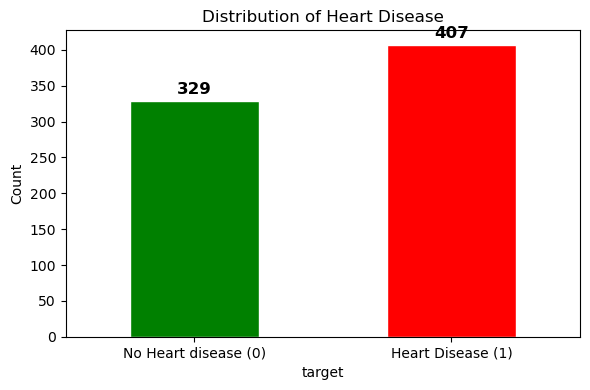

Class balance: 329 non-heart disease (44.7%) vs 407 heart disease (55.3%)


In [20]:
# ── Traget class balance ──
fig, ax = plt.subplots(figsize=(6, 4))
train_df['target'].value_counts().sort_index().plot.bar(
    ax=ax, color=['green', 'red'], edgecolor='white')
ax.set_xticklabels(['No Heart disease (0)', 'Heart Disease (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Distribution of Heart Disease')
for i, v in enumerate(train_df['target'].value_counts().sort_index()):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class balance: {(target==0).sum()} non-heart disease ({(target==0).mean():.1%}) vs "
      f"{(target==1).sum()} heart disease ({(target==1).mean():.1%})")

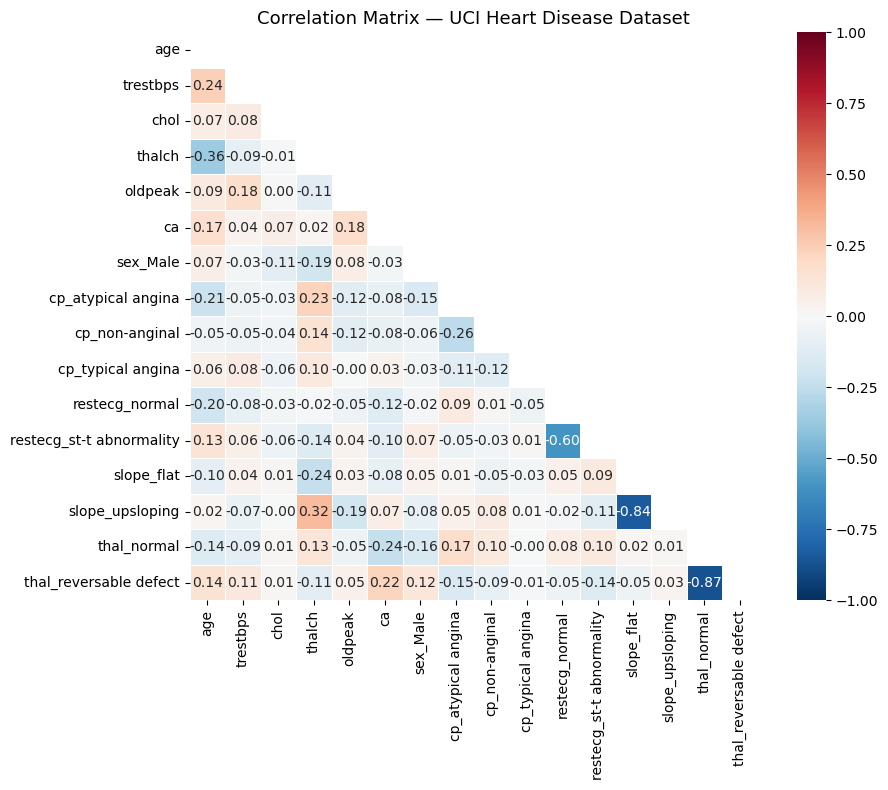

In [21]:
# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — UCI Heart Disease Dataset', fontsize=13)
plt.tight_layout()
plt.show()

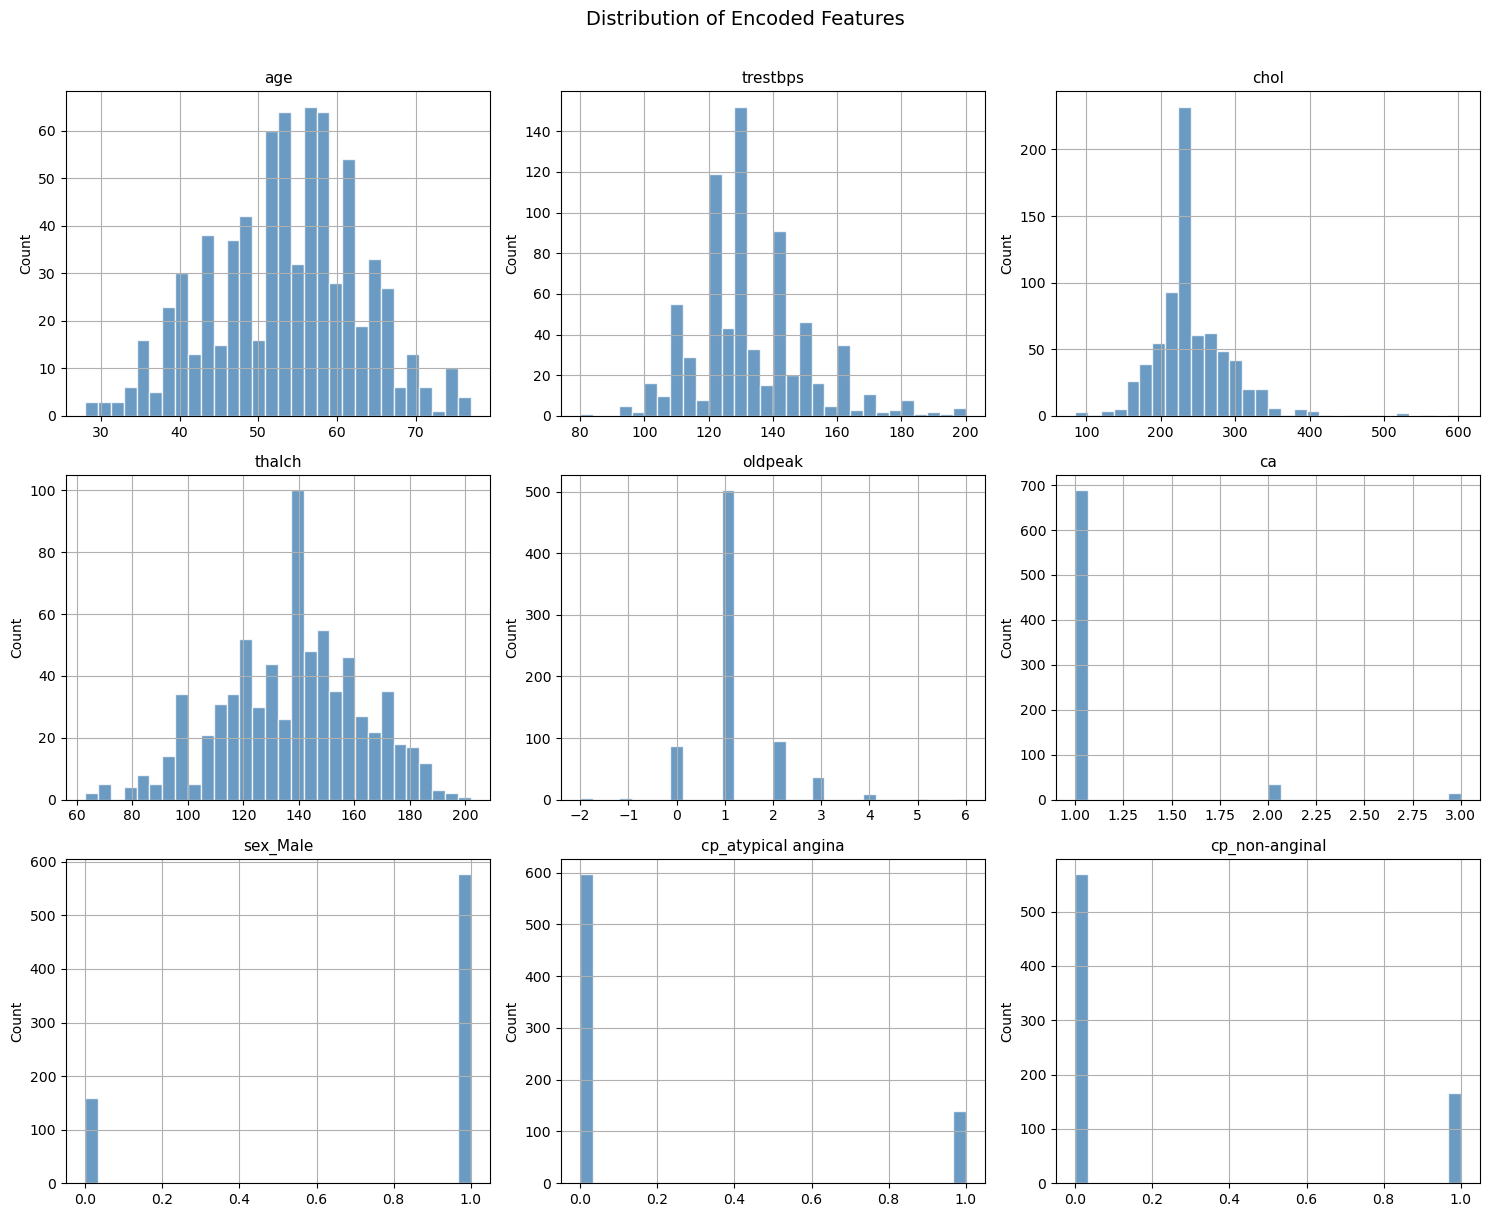

In [22]:

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), features.columns):
    features[col].hist(bins=30, ax=ax, edgecolor='white', alpha=0.8, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Count')
fig.suptitle('Distribution of Encoded Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 5. Modéles :

In [23]:
# ======================================================
# LOGISTIC REGRESSION --- Heart Disease Classification
# ======================================================

X = features
y = target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)

# Predict
y_pred_c = log_reg.predict(X_test_c)
y_prob_c = log_reg.predict_proba(X_test_c)[:, 1]  # Probability of class 1

# Evaluate
conf_matrix = confusion_matrix(y_test_c, y_pred_c)
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("═" * 55)
print("  LOGISTIC REGRESSION -- Heart Disease Prediction")
print("═" * 55)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("═" * 55)


═══════════════════════════════════════════════════════
  LOGISTIC REGRESSION -- Heart Disease Prediction
═══════════════════════════════════════════════════════
  Accuracy  : 0.7703
  Precision : 0.7727
  Recall    : 0.8293
  F1-Score  : 0.8000
═══════════════════════════════════════════════════════


c:\Users\bmd tech\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


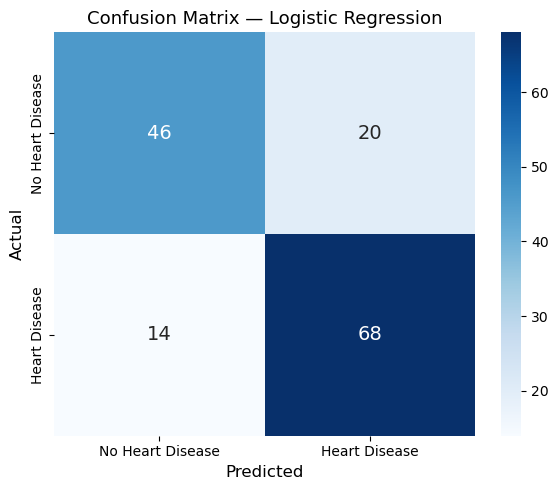

── Confusion Matrix Breakdown ──
  True Negatives  (correctly ruled out):      46
  False Positives (false alarms):             20
  False Negatives (MISSED diabetics):         14
  True Positives  (correctly identified):     68

💡 14 patients with Heart Disease were MISSED in a screening context,
   these are the most concerning errors.


In [24]:
# ── Confusion Matrix Visualisation ──
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'],
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = conf_matrix.ravel()
print("── Confusion Matrix Breakdown ──")
print(f"  True Negatives  (correctly ruled out):      {tn}")
print(f"  False Positives (false alarms):             {fp}")
print(f"  False Negatives (MISSED diabetics):         {fn}")
print(f"  True Positives  (correctly identified):     {tp}")
print(f"\n💡 {fn} patients with Heart Disease were MISSED in a screening context,")
print(f"   these are the most concerning errors.")

In [25]:
# --- Detailed Classification Report ---
print("-- Full Classification Report --\n")
print(classification_report(y_test_c, y_pred_c,
                target_names=['No Heart Disease', 'Heart Disease']))

-- Full Classification Report --

                  precision    recall  f1-score   support

No Heart Disease       0.77      0.70      0.73        66
   Heart Disease       0.77      0.83      0.80        82

        accuracy                           0.77       148
       macro avg       0.77      0.76      0.77       148
    weighted avg       0.77      0.77      0.77       148



In [28]:
# ── 5-Fold Stratified Cross-Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=cv, scoring='accuracy')

print("═" * 55)
print("  5-FOLD CROSS-VALIDATION Logistic Regression")
print("═" * 55)
for i, score in enumerate(cv_accuracy, 1):
    bar = "█" * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")
print(f"\n  Mean Accuracy : {cv_accuracy.mean():.4f}")
print(f"  Std Deviation : {cv_accuracy.std():.4f}")
print("═" * 55)

c:\Users\bmd tech\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\bmd tech\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

═══════════════════════════════════════════════════════
  5-FOLD CROSS-VALIDATION Logistic Regression
═══════════════════════════════════════════════════════
  Fold 1: 0.7635  ██████████████████████████████
  Fold 2: 0.7823  ███████████████████████████████
  Fold 3: 0.7959  ███████████████████████████████
  Fold 4: 0.7755  ███████████████████████████████
  Fold 5: 0.8163  ████████████████████████████████

  Mean Accuracy : 0.7867
  Std Deviation : 0.0181
═══════════════════════════════════════════════════════


c:\Users\bmd tech\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\bmd tech\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n